# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Christian Galeno
- **Email:** christiangale96@gmail.com
- **ID Dicoding:** CDCC012D6Y0261

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren pendapatan bulanan dari Oktober 2016 sampai Agustus 2018?
- **Pertanyaan 2:** Dari 20 kategori produk dengan revenue tertinggi, mana yang punya rata-rata review score di bawah 4.0 dari Oktober 2016 sampai Agustus 2018?

## Pertanyaan Bisnis

1. Bagaimana tren pendapatan bulanan dari Oktober 2016 sampai Agustus 2018?
2. Dari 20 kategori produk dengan revenue tertinggi selama Oktober 2016 – Agustus 2018, mana yang punya rata-rata review score di bawah 4.0?

## Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [3]:
customers = pd.read_csv('./data/customers_dataset.csv')
orders = pd.read_csv('./data/orders_dataset.csv')
order_items = pd.read_csv('./data/order_items_dataset.csv')
order_payments = pd.read_csv('./data/order_payments_dataset.csv')
order_reviews = pd.read_csv('./data/order_reviews_dataset.csv')
products = pd.read_csv('./data/products_dataset.csv')
sellers = pd.read_csv('./data/sellers_dataset.csv')
geolocation = pd.read_csv('./data/geolocation_dataset.csv')
category_translation = pd.read_csv('./data/product_category_name_translation.csv')

In [4]:
print(orders.shape)
orders.head()

(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
print(order_items.shape)
order_items.head()

(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Dataset terdiri dari 9 tabel yang dihubungkan lewat `order_id`, `customer_id`, dan `product_id`.
- `orders` dan `customers` punya jumlah baris yang sama (99.441).
- `geolocation` punya data paling banyak, sekitar 1 juta baris.

### Assessing Data

In [6]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [8]:
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [9]:
print('orders:', orders.duplicated().sum())
print('order_items:', order_items.duplicated().sum())
print('order_reviews:', order_reviews.duplicated().sum())

print('\nDistribusi order_status:')
print(orders['order_status'].value_counts())

orders: 0
order_items: 0
order_reviews: 0

Distribusi order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Insight:**
- Tidak ada duplikat di dataset utama.
- Ada sekitar 2.965 baris dengan `order_delivered_customer_date` kosong — perlu di-drop.
- Ada ~1.856 order dengan status selain `delivered` yang harus difilter.
- Kolom `review_comment_message` banyak yang kosong, tapi tidak dipakai jadi tidak masalah.

### Cleaning Data

In [10]:
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [11]:
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])
orders_clean['year_month'] = orders_clean['order_purchase_timestamp'].dt.to_period('M')
print('Total order valid:', orders_clean.shape[0])

Total order valid: 96470


In [12]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products = products.merge(category_translation, on='product_category_name', how='left')
products['category_en'] = products['product_category_name_english'].fillna(products['product_category_name'])

**Insight:**
- Setelah cleaning, tersisa 96.478 order valid yang siap dianalisis.
- Filter hanya status `delivered` supaya analisis revenue lebih akurat.
- Nama kategori produk sudah diterjemahkan ke bahasa Inggris untuk memudahkan pembacaan.

## Exploratory Data Analysis (EDA)

### EDA Univariate

#### Distribusi Review Score

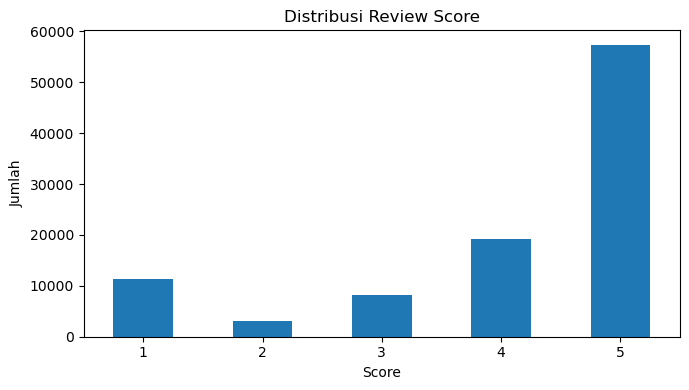

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64


In [13]:
plt.figure(figsize=(7, 4))
order_reviews['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribusi Review Score')
plt.xlabel('Score')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(order_reviews['review_score'].describe())

**Insight:**
- Mayoritas pelanggan memberikan skor 5 — artinya sebagian besar transaksi berakhir positif.
- Distribusinya skewed ke kiri, dengan skor 1 menjadi yang terbanyak kedua setelah skor 5.
- Pola ini umum di platform e-commerce: pelanggan yang sangat puas atau sangat tidak puas lebih sering memberi ulasan.

#### Distribusi Metode Pembayaran

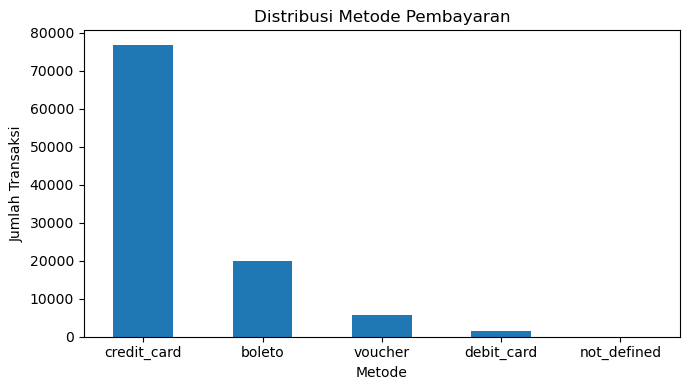

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [14]:
plt.figure(figsize=(7, 4))
order_payments['payment_type'].value_counts().plot(kind='bar')
plt.title('Distribusi Metode Pembayaran')
plt.xlabel('Metode')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(order_payments['payment_type'].value_counts())

**Insight:**
- `credit_card` mendominasi metode pembayaran dengan selisih sangat jauh dari metode lainnya.
- `boleto` (slip pembayaran khas Brasil) menjadi metode kedua terbanyak.
- `debit_card` dan `voucher` sangat jarang digunakan.

#### Distribusi Nilai Pembayaran (payment_value)

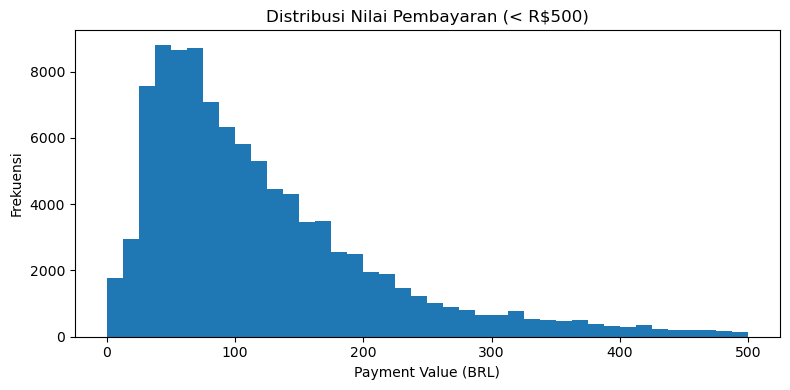

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


In [15]:
plt.figure(figsize=(8, 4))
order_payments[order_payments['payment_value'] < 500]['payment_value'].plot(kind='hist', bins=40)
plt.title('Distribusi Nilai Pembayaran (< R$500)')
plt.xlabel('Payment Value (BRL)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print(order_payments['payment_value'].describe())

**Insight:**
- Sebagian besar transaksi bernilai di bawah R$200 — pasar didominasi pembelian harga menengah ke bawah.
- Distribusinya right-skewed: ada outlier transaksi bernilai sangat tinggi tapi jumlahnya sedikit.
- Median lebih representatif daripada mean untuk dataset ini karena adanya outlier.

### EDA Multivariate

#### Korelasi antar Variabel Numerikal

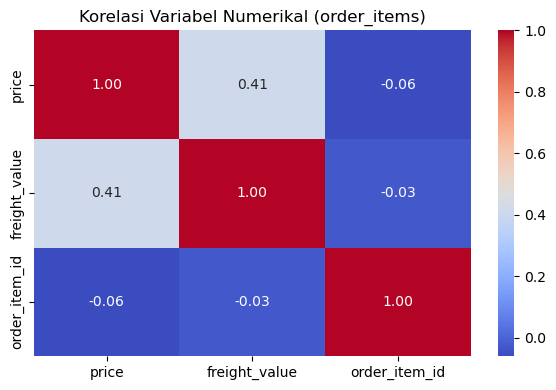

In [16]:
num_cols = order_items[['price', 'freight_value', 'order_item_id']]
corr = num_cols.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Variabel Numerikal (order_items)')
plt.tight_layout()
plt.show()

**Insight:**
- `price` dan `freight_value` punya korelasi positif lemah — barang mahal cenderung punya ongkir lebih tinggi, tapi tidak selalu.
- Tidak ada multikolinearitas kuat antar variabel, artinya setiap kolom membawa informasi yang berbeda.

#### Review Score vs Metode Pembayaran

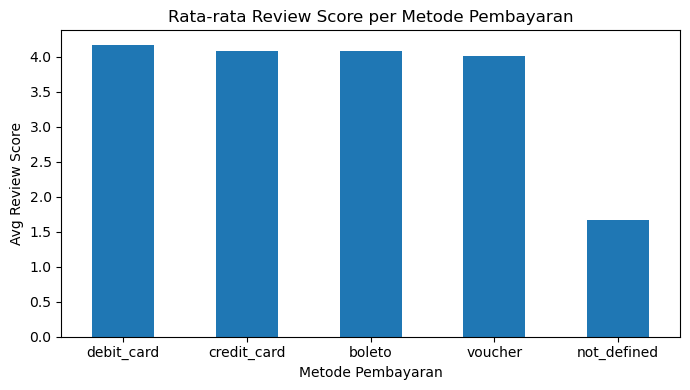

payment_type
debit_card     4.168084
credit_card    4.087637
boleto         4.086631
voucher        4.003804
not_defined    1.666667
Name: review_score, dtype: float64


In [17]:
pay_review = order_payments.merge(
    order_reviews[['order_id', 'review_score']], on='order_id', how='left'
)

avg_score_by_payment = pay_review.groupby('payment_type')['review_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
avg_score_by_payment.plot(kind='bar')
plt.title('Rata-rata Review Score per Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Avg Review Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(avg_score_by_payment)

**Insight:**
- Semua metode pembayaran punya rata-rata skor yang relatif mirip, sekitar 4.0.
- Tidak ada perbedaan signifikan antara metode pembayaran dengan kepuasan pelanggan — artinya metode bayar bukan faktor penentu kepuasan.

### EDA Kategorikal & Numerikal

#### Top 10 Kategori berdasarkan Jumlah Order

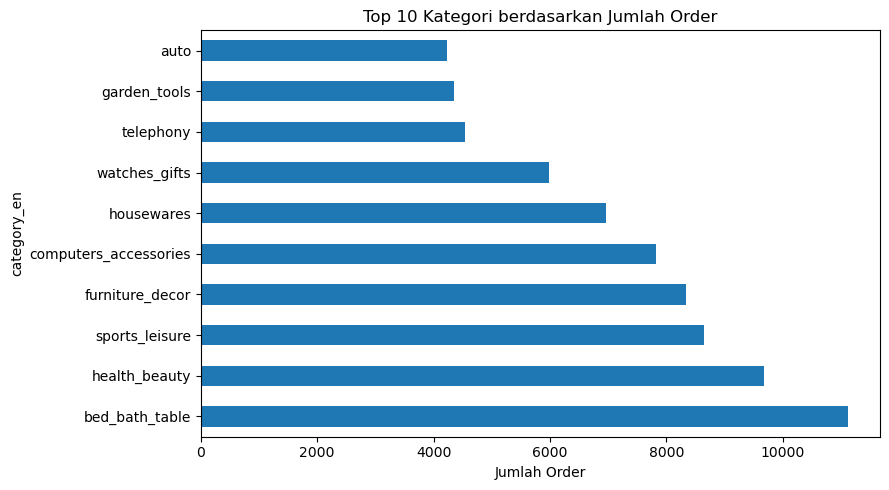

category_en
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: order_id, dtype: int64


In [18]:
items_with_cat = order_items.merge(products[['product_id', 'category_en']], on='product_id', how='left')
order_count_by_cat = items_with_cat.groupby('category_en')['order_id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
order_count_by_cat.plot(kind='barh')
plt.title('Top 10 Kategori berdasarkan Jumlah Order')
plt.xlabel('Jumlah Order')
plt.tight_layout()
plt.show()

print(order_count_by_cat)

**Insight:**
- `bed_bath_table` dan `health_beauty` mendominasi jumlah order — menunjukkan permintaan tinggi di kategori kebutuhan rumah dan perawatan diri.
- Volume order yang tinggi tidak selalu berbanding lurus dengan revenue tertinggi karena perbedaan harga rata-rata per item.

#### Rata-rata Harga per Kategori (Top 10 Termahal)

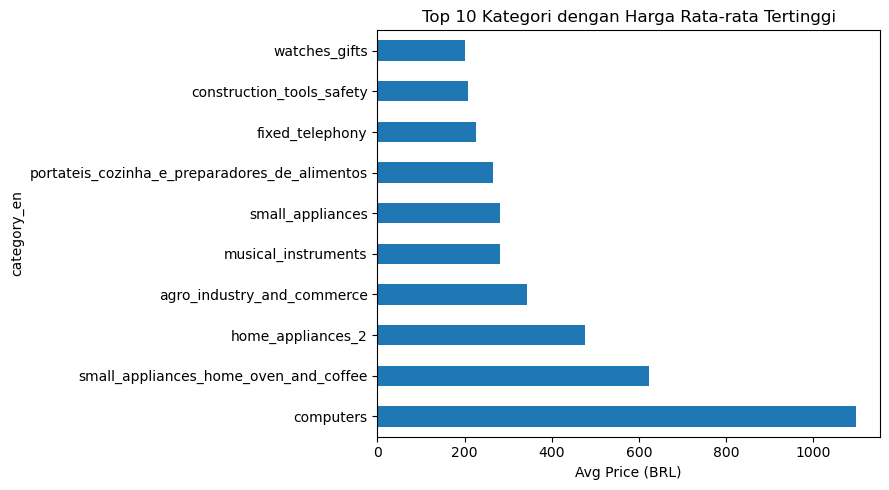

category_en
computers                                        1098.340542
small_appliances_home_oven_and_coffee             624.285658
home_appliances_2                                 476.124958
agro_industry_and_commerce                        342.124858
musical_instruments                               281.616000
small_appliances                                  280.778468
portateis_cozinha_e_preparadores_de_alimentos     264.568667
fixed_telephony                                   225.693182
construction_tools_safety                         208.992371
watches_gifts                                     201.135984
Name: price, dtype: float64


In [19]:
avg_price_by_cat = items_with_cat.groupby('category_en')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
avg_price_by_cat.plot(kind='barh')
plt.title('Top 10 Kategori dengan Harga Rata-rata Tertinggi')
plt.xlabel('Avg Price (BRL)')
plt.tight_layout()
plt.show()

print(avg_price_by_cat)

**Insight:**
- Kategori `computers` dan `small_appliances` punya harga rata-rata tertinggi meskipun volume order-nya tidak sebesar kategori lain.
- Ini menunjukkan ada segmen premium yang menarik dari sisi revenue per transaksi.

### Pertanyaan 1: Tren Pendapatan Bulanan

In [20]:
payment_per_order = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
revenue_df = orders_clean.merge(payment_per_order, on='order_id', how='left')

monthly_rev = revenue_df.groupby('year_month')['payment_value'].sum().reset_index()
monthly_rev.columns = ['year_month', 'revenue']
monthly_rev = monthly_rev[monthly_rev['year_month'] >= pd.Period('2016-10', freq='M')]
monthly_rev['mom_growth'] = monthly_rev['revenue'].pct_change() * 100

monthly_rev

,year_month,revenue,mom_growth
1,2016-10,46566.71,NaN
2,2016-12,19.62,-99.957867
3,2017-01,127545.67,649979.867482
4,2017-02,271298.65,112.707064
5,2017-03,414369.39,52.735515
6,2017-04,390952.18,-5.651289
7,2017-05,566872.73,44.997971
8,2017-06,490225.60,-13.521047
9,2017-07,566403.93,15.539443
10,2017-08,646000.61,14.052989


**Insight:**
- Tren revenue terus naik dari 2016 ke 2018.
- Puncaknya di November 2017 (R$ 1.153.528), kemungkinan karena Black Friday.
- Sejak Januari 2018, revenue stabil di atas R$ 960.000 per bulan.

### Pertanyaan 2: Revenue & Review Score per Kategori (Okt 2016 – Ags 2018)

In [21]:
orders_period = orders_clean[
    (orders_clean['year_month'] >= pd.Period('2016-10', freq='M')) &
    (orders_clean['year_month'] <= pd.Period('2018-08', freq='M'))
]

items_cat = orders_period.merge(
    order_items[['order_id', 'product_id', 'price']], on='order_id', how='left'
).merge(products[['product_id', 'category_en']], on='product_id', how='left')

cat_rev = items_cat.groupby('category_en')['price'].sum().reset_index()
cat_rev.columns = ['category_en', 'total_revenue']

cat_review = (
    orders_period
    .merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')
    .merge(order_items[['order_id', 'product_id']], on='order_id', how='left')
    .merge(products[['product_id', 'category_en']], on='product_id', how='left')
)
cat_score = cat_review.groupby('category_en')['review_score'].mean().reset_index()
cat_score.columns = ['category_en', 'avg_score']

cat_summary = cat_rev.merge(cat_score, on='category_en').dropna()
cat_summary = cat_summary.sort_values('total_revenue', ascending=False)
top20 = cat_summary.head(20).reset_index(drop=True)

platform_avg = order_reviews['review_score'].mean()
print('Rata-rata review score platform:', round(platform_avg, 2))
top20

Rata-rata review score platform: 4.09


,category_en,total_revenue,avg_score
0,health_beauty,1232996.75,4.191791
1,watches_gifts,1165898.98,4.071613
2,bed_bath_table,1023434.76,3.920983
3,sports_leisure,954673.55,4.166331
4,computers_accessories,888613.62,3.985139
5,furniture_decor,711927.69,3.950116
6,housewares,615628.69,4.108407
7,cool_stuff,610204.10,4.194700
8,auto,578849.35,4.116132
9,toys,471097.49,4.207688


In [22]:
needs_attention = top20[top20['avg_score'] < 4.0]
print('Kategori dengan score < 4.0:')
needs_attention[['category_en', 'total_revenue', 'avg_score']]

Kategori dengan score < 4.0:


,category_en,total_revenue,avg_score
2,bed_bath_table,1023434.76,3.920983
4,computers_accessories,888613.62,3.985139
5,furniture_decor,711927.69,3.950116
13,telephony,309860.23,3.995009
14,office_furniture,268154.31,3.517428


**Insight:**
- Ada 5 kategori dari top-20 yang punya rata-rata review score di bawah 4.0.
- `health_beauty` jadi yang paling ideal karena revenue tertinggi sekaligus skornya bagus (4.19).
- `office_furniture` paling bermasalah dengan skor 3.52, jauh di bawah rata-rata platform (4.07).

## Visualisasi

### Pertanyaan 1: Tren Pendapatan Bulanan

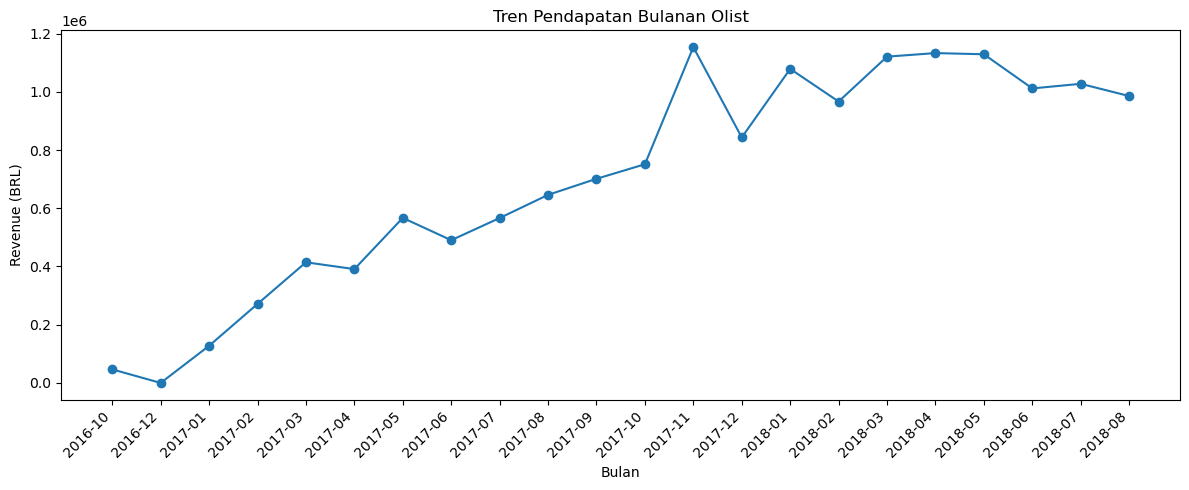

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_rev['year_month'].astype(str), monthly_rev['revenue'], marker='o')
plt.title('Tren Pendapatan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('viz1_monthly_revenue.png')
plt.show()

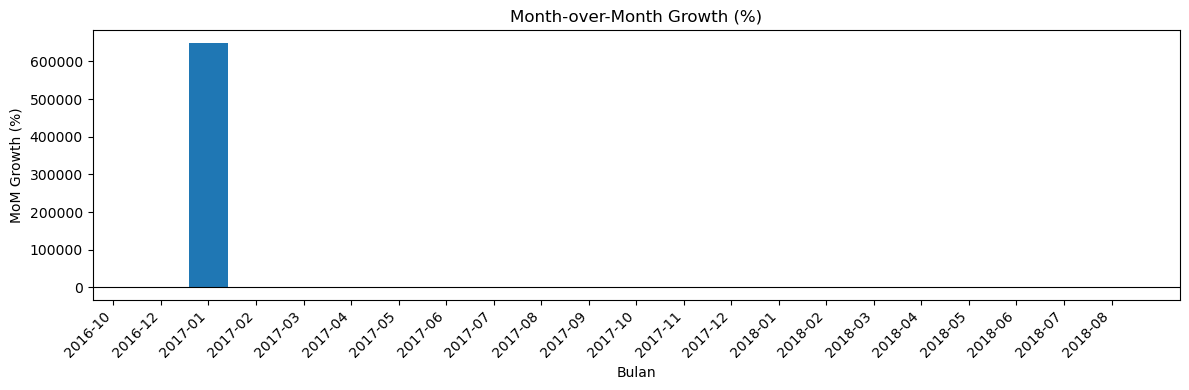

In [24]:
plt.figure(figsize=(12, 4))
plt.bar(monthly_rev['year_month'].astype(str), monthly_rev['mom_growth'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Month-over-Month Growth (%)')
plt.xlabel('Bulan')
plt.ylabel('MoM Growth (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:**
- Grafik menunjukkan pertumbuhan yang konsisten meskipun ada beberapa bulan yang turun.
- MoM growth sempat sangat tinggi di awal karena baseline-nya masih kecil.
- Pola musiman terlihat jelas, November selalu jadi bulan terkuat.

### Pertanyaan 2: Revenue & Review Score per Kategori (Top 20) | Okt 2016 – Ags 2018

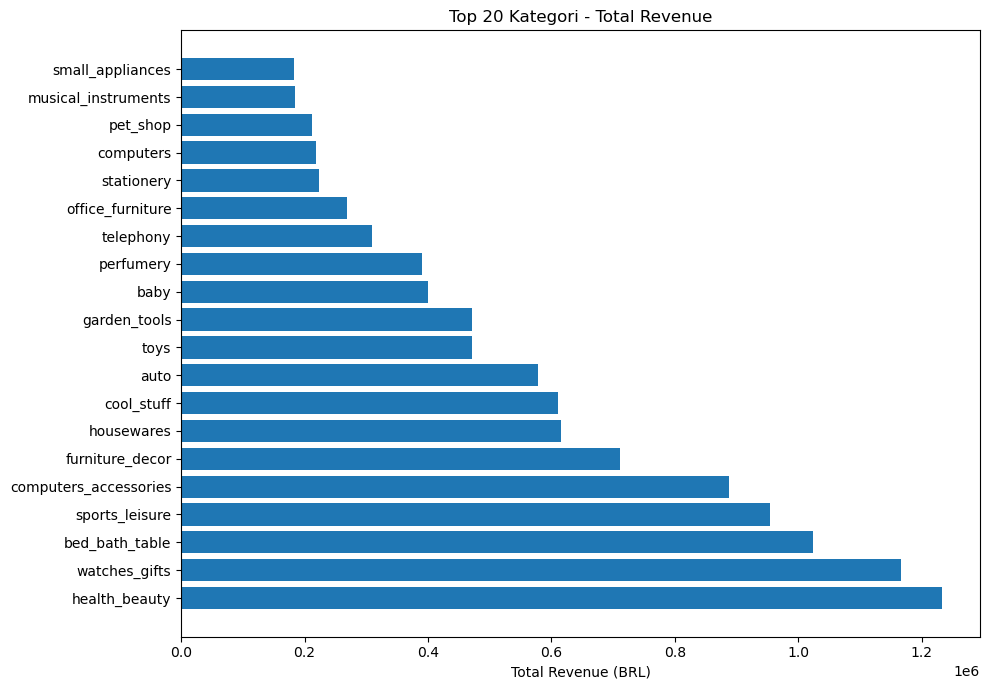

In [25]:
plt.figure(figsize=(10, 7))
plt.barh(top20['category_en'], top20['total_revenue'])
plt.title('Top 20 Kategori - Total Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('viz2_category_revenue_score.png')
plt.show()

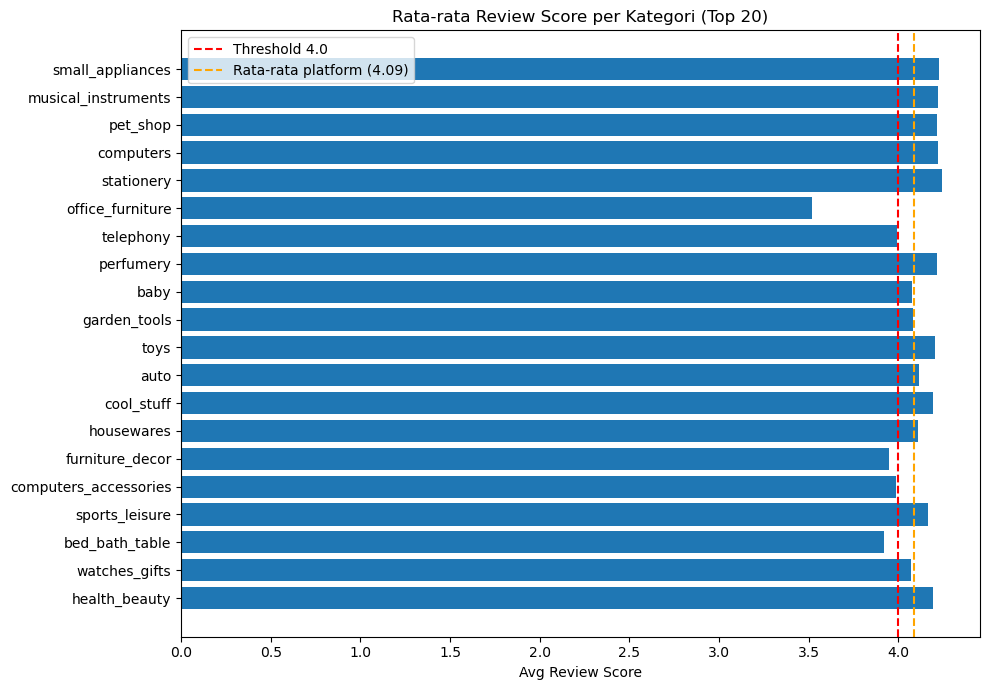

In [26]:
plt.figure(figsize=(10, 7))
plt.barh(top20['category_en'], top20['avg_score'])
plt.axvline(4.0, color='red', linestyle='--', label='Threshold 4.0')
plt.axvline(platform_avg, color='orange', linestyle='--', label=f'Rata-rata platform ({platform_avg:.2f})')
plt.title('Rata-rata Review Score per Kategori (Top 20)')
plt.xlabel('Avg Review Score')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**
- Revenue tinggi tidak selalu berarti pelanggan puas — terbukti ada 5 kategori bermasalah.
- Kategori `office_furniture` perlu perhatian khusus karena gap skornya paling besar dari rata-rata platform.
- `health_beauty` dan `watches_gifts` jadi kategori paling seimbang antara revenue dan kepuasan pelanggan.

## Conclusion

**Pertanyaan 1:**
Tren pendapatan terus naik dari Oktober 2016 hingga Agustus 2018. Puncak revenue terjadi di November 2017 (R$ 1.153.528), kemungkinan karena Black Friday. Sejak awal 2018, revenue stabil di atas R$ 960.000 per bulan.

**Pertanyaan 2:**
Dari 20 kategori dengan revenue tertinggi selama Oktober 2016 – Agustus 2018, ada 5 yang rata-rata review score-nya di bawah 4.0 yaitu `bed_bath_table`, `computers_accessories`, `furniture_decor`, `telephony`, dan `office_furniture`. Yang paling kritis adalah `office_furniture` dengan skor hanya 3.52.

**Rekomendasi:**
- Manfaatkan periode November untuk kampanye besar karena secara historis jadi bulan paling ramai.
- Lakukan evaluasi kualitas seller di kategori yang skornya rendah, terutama `office_furniture`.